In [ ]:
#Importing Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import zscore

In [ ]:
#Mount the Google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Load the dataset
file_path = '/content/drive/My Drive/insurance.csv'
insurance_data = pd.read_csv(file_path)

In [ ]:
#Display first 5 rows in dataframe
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
#Total rowsin count
len(insurance_data)

1338

In [ ]:
#Summary statistics
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


#Exploratory Data Analysis

In [ ]:
#Display if any missing values
insurance_data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
#Check for duplicates
insurance_data.duplicated().sum()

1

In [ ]:
#Drop the Duplicated row
insurance_data.drop_duplicates(inplace=True)

In [ ]:
#Earlier there were 1338 rows and after removing the duplicated ones
len(insurance_data)

1337

In [ ]:
#Data types of each column
insurance_data.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
#Convert the necessary data type
insurance_data['sex'] = insurance_data['sex'].astype('category')
insurance_data['smoker'] = insurance_data['smoker'].astype('category')
insurance_data['region'] = insurance_data['region'].astype('category')
insurance_data.dtypes

,0
age,int64
sex,category
bmi,float64
children,int64
smoker,category
region,category
charges,float64


In [ ]:
#Display unique values in categorical columns
print(insurance_data['sex'].unique())
print(insurance_data['smoker'].unique())
print(insurance_data['region'].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


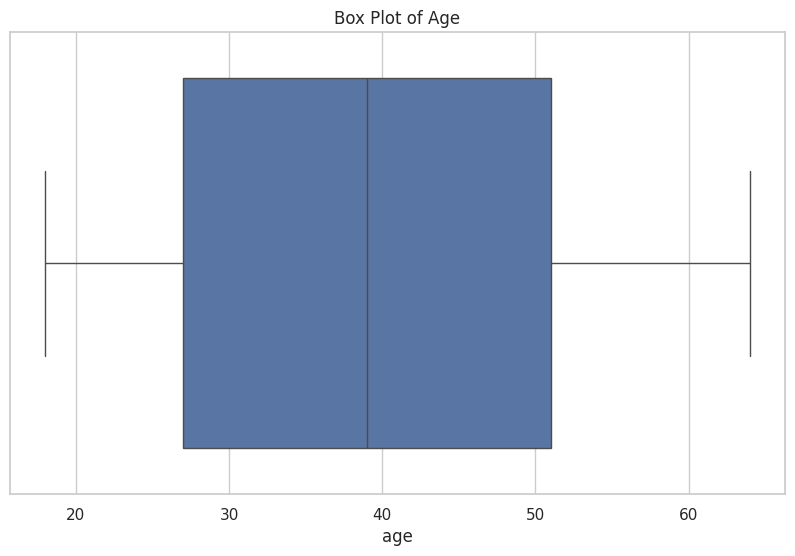

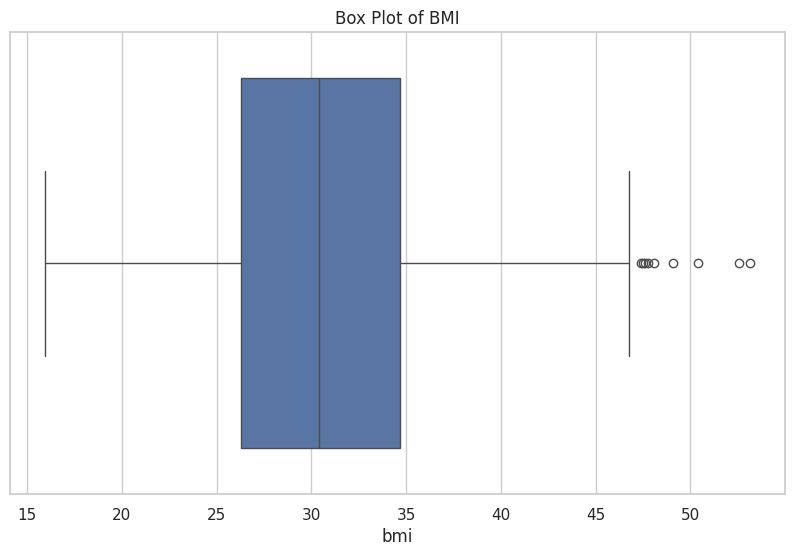

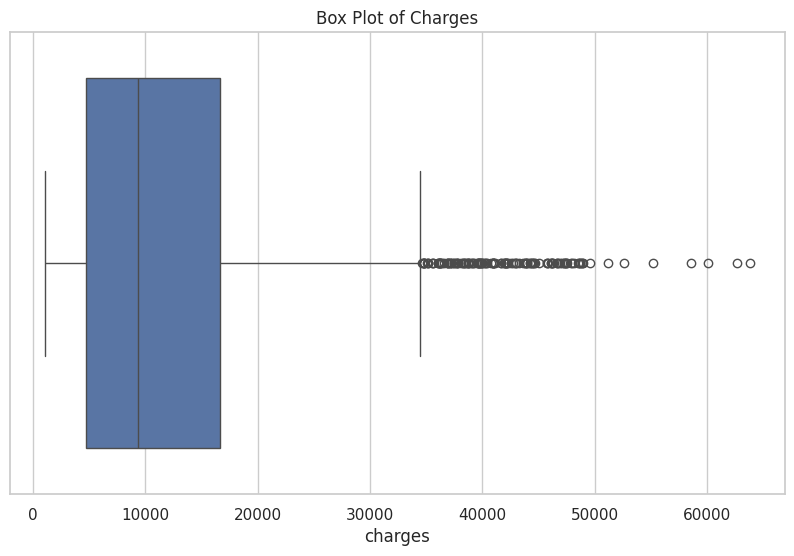

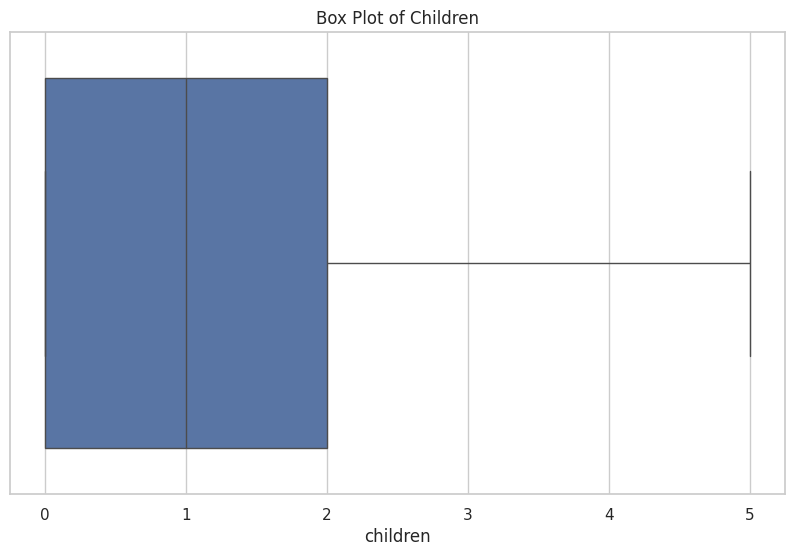

<Figure size 640x480 with 0 Axes>

In [ ]:
#Visualize outliers in age, bmi, children and charges
plt.figure(figsize=(10, 6))
sns.boxplot(x='age', data=insurance_data)
plt.title('Box Plot of Age')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='bmi', data=insurance_data)
plt.title('Box Plot of BMI')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='charges', data=insurance_data)
plt.title('Box Plot of Charges')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='children', data=insurance_data)
plt.title('Box Plot of Children')
plt.show()

plt.tight_layout()
plt.show()

###Box Plot for Outliers
Purpose:
The goal of box plots is to show the data distribution and highlight any outliers. Extreme data that fall much outside of the normal range are known as outliers and can have an impact on analysis.

For the four main variables, the box plots:
Age: This parameter identifies outliers in the sample that can be very young or old people.

The Body Mass Index, or BMI, draws attention to extreme values where a person is noticeably underweight or overweight.

Charges (Medical Costs): Indicates anomalies with exceptionally high medical expenses that may have an impact on insurance analysis.

Children (Number of Dependents): Indicates which families have a disproportionately large number of kids.

Observation: The interquartile range, or middle 50% of the data, is shown by the box.
The median, or midway value, is displayed on the line inside the box.

Outliers are the dots (very high or low ) that are not inside the box.


In [ ]:
#Handle outliers using the zscore method for numerical columns
insurance_data_new =  insurance_data[
    (zscore(insurance_data['age']).abs() < 3) &
    (zscore(insurance_data['bmi']).abs() < 3) &
    (zscore(insurance_data['children']).abs() < 3) &
    (zscore(insurance_data['charges']).abs() < 3)
].copy()
insurance_data_new.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


###Handling Outliers using z-score
Goal: To manage outliers in numerical columns like age, bmi, children, and charges, we are employing the Z-score approach. Values that deviate significantly from the mean are called outliers, and the Z-score aids in data normalization.

The Z-Score's Functions:
A data point's distance from the mean expressed in standard deviations is shown by the Z-score.

Working:
As a general rule, an outlier is indicated by a Z-score that is larger than or equal to 3. Only rows that have an absolute Z-score of less than three for each value (i.e., those that fall within the typical range) are kept.

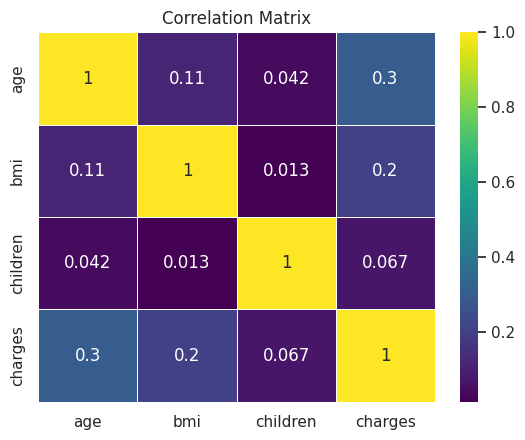

In [ ]:
#Check for Correlations between Numerical variables
# Filter only numeric columns
correlation_matrix = insurance_data.select_dtypes(include=np.number).corr()
correlation_matrix
#Visualizing correlation heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', linewidths=0.7)
plt.title('Correlation Matrix')
plt.show()

###Correlation matrix of numerical values
Purpose: The goal is to determine the correlations between the important numerical factors (children, age, bmi, charges), as well as their effects on insurance costs.

Heatmap: Uses color gradients to visually represent correlations between variables.

Correlations: 0 indicates no association, and values vary from 1 (strong positive) to -1 (strong negative).

Working:
There are moderately favorable associations (0.3 and 0.2) between charges and age and BMI.
Children barely affect charges (0.067).


In [ ]:
# Save the cleaned data into a CSV file
insurance_data_new.to_csv('cleaned_insurance_data.csv', index=False)

# This is how you can download it in a Google Colab environment
from google.colab import files
files.download('cleaned_insurance_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Data Vizualisation

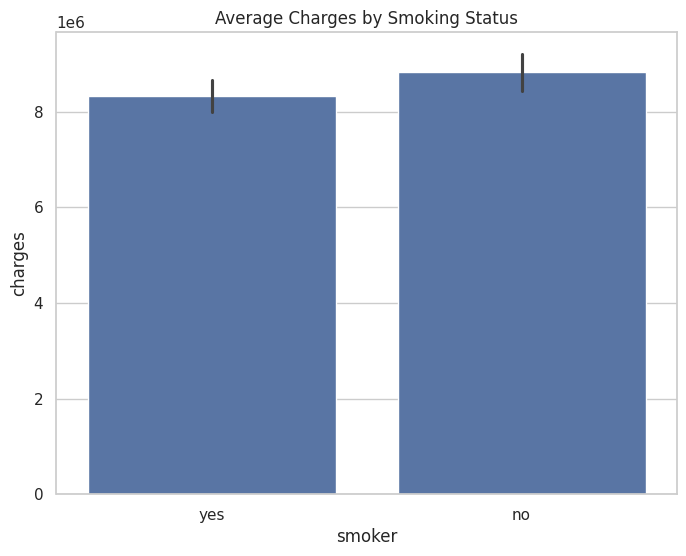

In [ ]:
#Bar plot for smoking status vs average charges
plt.figure(figsize=(8, 6))
sns.barplot(x='smoker', y='charges', data=insurance_data_new, estimator=sum)
plt.title('Average Charges by Smoking Status')
plt.show()

###Smoking Status vs Charges

Purpose: The goal is to determine the correlations between the important numerical factors (children, age, bmi, charges), as well as their effects on insurance costs.

Goal:To examine the connection between insurance costs and smoking status.

Illustration:
The entire insurance costs are displayed in a bar plot according to smoking status.

This makes it easier to determine if smokers and non-smokers pay different prices.

Important Takeaways:
The entire amount of charges for smokers versus non-smokers is displayed by the bar heights.

Important variables:
x-axis: Yes/No status of smoking.

y-axis: Total amount of insurance costs.

Explanation: According to overlapping confidence ranges, smokers in this dataset had a somewhat lower total charge than non-smokers, although the differences may not be statistically significant.

Non-smokers: Pay a little bit more overall in this particular instance.

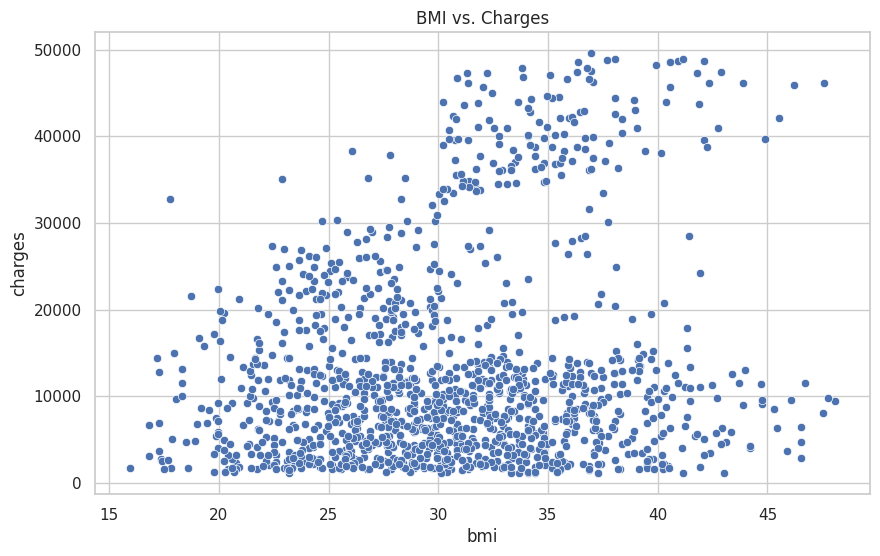

In [ ]:
#scatter plot for BMI vs charges
plt.figure(figsize=(10, 6))
sns.scatterplot(x='bmi', y='charges', data=insurance_data_new)
plt.title('BMI vs. Charges')
plt.show()

###Scatter plot for BMI vs Charges
The association between insurance charges (y-axis) and BMI (x-axis) is shown visually in a scatter plot.

Insights: Displays how prices vary depending on a person's BMI.

Purpose: Finding trends or patterns between BMI and charges is the aim of this study, with greater BMI typically being associated with higher charges.

Observation: A few groups centered on BMIs between 30 and 35 indicate rising costs, suggesting that those with higher BMIs may have greater healthcare costs.

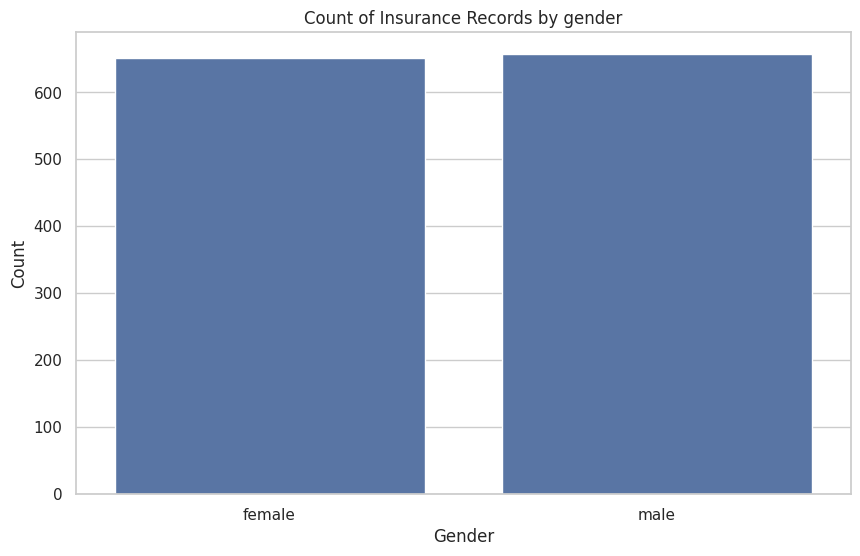

In [ ]:
#Count plot for categorical variables
plt.figure(figsize=(10, 6))
sns.countplot(x='sex', data=insurance_data_new)
plt.title('Count of Insurance Records by gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

###Count Plot for Categorical variable gender
Count Plot: Shows the frequency of insurance records by gender (count on the y-axis, gender on the x-axis).

Categorical data can be visualized with sns.countplot. The number of records in the dataset for each gender is counted here.

Insight: There are almost equal numbers of male and female records in the dataset.

Usefulness: Aids in comprehending the dataset's gender distribution.

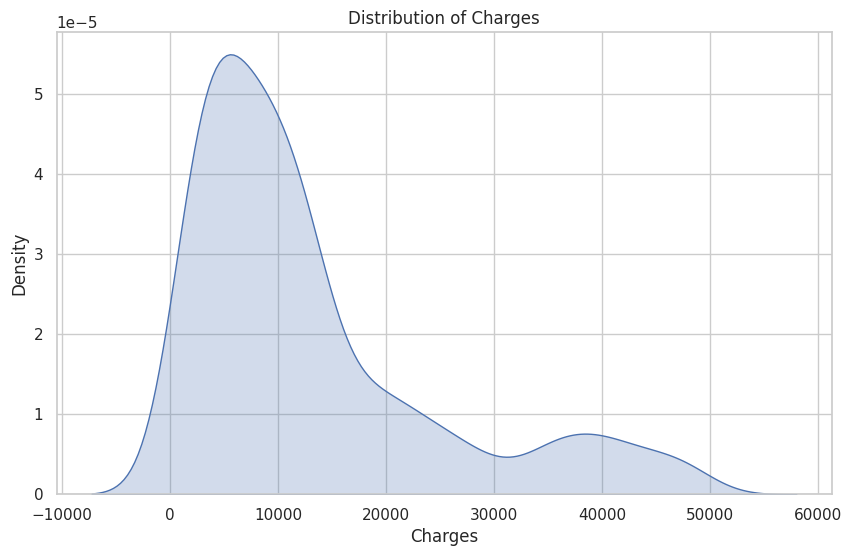

In [ ]:
#Kernel Density Estimation plot to see visualization of charges
plt.figure(figsize=(10, 6))
sns.kdeplot(data=insurance_data_new, x='charges', fill=True)
plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Density')
plt.show()



###Kernel Density (KDE) for Insurance Charges
KDE: A non-parametric method for calculating a continuous variable's probability density function.

Goal: Provides a visual representation of the dataset's "charges" distribution.
With the majority of the charges clustered between 0 and 15,000, the plot displays a skewed distribution.

Long tail: A few number of high charges surpass 30,000.

Findings: The majority of people pay less for insurance; a small number pay much more.

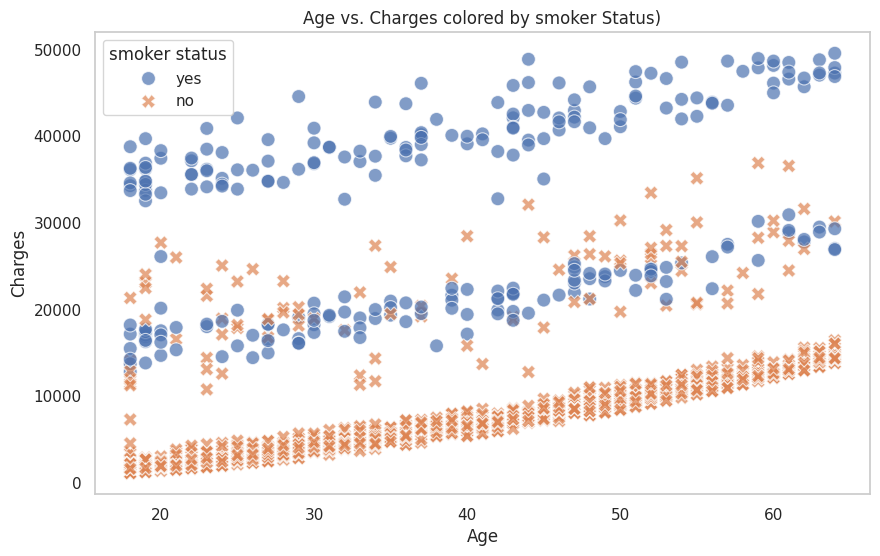

In [ ]:
#scatter plot
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', hue='smoker', data=insurance_data_new, style='smoker',s=100, alpha=0.7)
plt.title('Age vs. Charges colored by smoker Status)')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(title='smoker status')
plt.grid()
plt.show()

###Scatter Plot - Age vs. Charges by Smoker Status

Goal: To show how age and insurance costs relate to one another while accounting for smoker status.

Plots individual data points for charges (y-axis) and age (x-axis) in a scatter plot.

Status of Smokers: Depending on whether the person smokes or not, points are outlined and color-coded (orange for non-smokers, blue for smokers).

Observations: Across all age categories, smokers (blue) tend to be charged higher, whereas non-smokers (orange) tend to be charged lower.

#Linear Regression

R-squared score: 0.7526781202567494


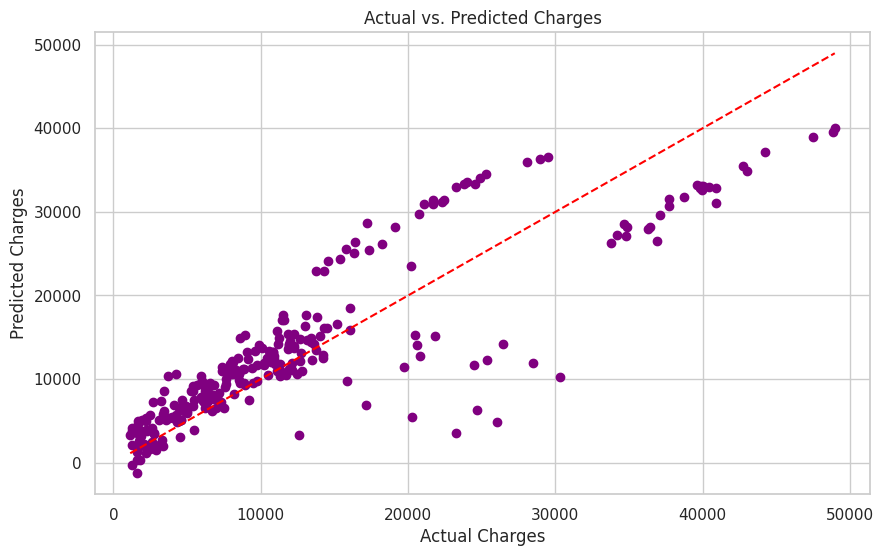

In [ ]:
import statsmodels.api as sm

#performing linear regression
insurance_data_new['smoker'] = insurance_data_new['smoker'].map({'yes': 1, 'no': 0})
x=insurance_data_new[['age','bmi','children','smoker']]
y=insurance_data_new['charges']

#Train and Test Split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(x_train, y_train)

#Predict on the test set
y_pred = model.predict(x_test)
r2 = r2_score(y_test, y_pred)
print(f"R-squared score: {r2}")

#visualize the preditcted values and actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='purple')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs. Predicted Charges')
plt.show()

###Actual vs. Predicted Charges (Linear Regression)
Goal: Using linear regression to forecast insurance costs depending on variables such as age, BMI, family size, and smoking status.

Linear regression: Forecasts charges with multiple features.

Visualization: Scatter plot with the predicted charges (y-axis) and actual charges (x-axis) compared.

observation: Better model performance is indicated by points that are closer to the red line, which represents the ideal prediction line.

Most points cluster near the red line, indicating good model performance, though some high-charge predictions deviate.

R-squared score: A metric for assessing the correctness of the model.
                 R² Score: 0.75 means the model is doing a fairly good job at predicting charges but can be improved by adding more features or improving the model's complexity.